In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, classification_report
)
from sklearn.preprocessing    import StandardScaler

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')


In [5]:

df = pd.read_csv(r"dataset\ml_ready.csv")
print(f"Shape : {df.shape}")
print(f"Target distribution:\n{df['is_low_score'].value_counts(normalize=True).mul(100).round(2)}")

Shape : (102472, 87)
Target distribution:
is_low_score
False    86.52
True     13.48
Name: proportion, dtype: float64


In [7]:
df

,actual_delivery_days,estimated_delivery_days,is_late,days_to_approve,days_to_carrier,total_price,total_freight,freight_ratio,price_per_item,count_items,...,product_category_name_english_security_and_services,product_category_name_english_signaling_and_security,product_category_name_english_small_appliances,product_category_name_english_small_appliances_home_oven_and_coffee,product_category_name_english_sports_leisure,product_category_name_english_stationery,product_category_name_english_tablets_printing_image,product_category_name_english_telephony,product_category_name_english_toys,product_category_name_english_watches_gifts
0,8.0,16,0,0.0,2.0,29.99,8.72,0.290764,29.99,1,...,0,0,0,0,0,0,0,0,0,0
1,8.0,16,0,0.0,2.0,29.99,8.72,0.290764,29.99,1,...,0,0,0,0,0,0,0,0,0,0
2,14.0,20,0,2.0,0.0,118.70,22.76,0.191744,118.70,1,...,0,0,0,0,0,0,0,0,0,0
3,9.0,27,0,0.0,0.0,159.90,19.22,0.120200,159.90,1,...,0,0,0,0,0,0,0,0,0,0
4,14.0,27,0,0.0,4.0,45.00,27.20,0.604444,45.00,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102467,8.0,19,0,0.0,1.0,72.00,13.08,0.181667,72.00,1,...,0,0,0,0,0,0,0,0,0,0
102468,22.0,24,0,0.0,1.0,174.90,20.10,0.114923,174.90,1,...,0,0,0,0,0,0,0,0,0,0
102469,25.0,31,0,0.0,1.0,205.99,65.02,0.315646,205.99,1,...,0,0,0,0,0,0,0,0,0,0
102470,17.0,38,0,0.0,4.0,359.98,81.18,0.225513,179.99,2,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# ── เลือก Features ──────────────────────────────────
# ตัด actual_delivery_days ออก เพราะ multicollinearity กับ is_late
base_features = [
    'is_late', 'days_to_carrier', 'days_to_approve',
    'count_items', 'total_price', 'freight_ratio',
    'price_per_item', 'max_installments', 'month_purchase',
]

# รวม one-hot columns ของ payment_type และ product_category
onehot_cols = [c for c in df.columns
               if c.startswith('payment_type_') or
                  c.startswith('product_category_')]

feature_cols = base_features + onehot_cols

X = df[feature_cols]
y = df['is_low_score']

print(f"X shape : {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape : (102472, 82)
y distribution:
is_low_score
False    88661
True     13811
Name: count, dtype: int64


In [9]:
# ── Split 80/20 ──────────────────────────────────────
# stratify=y → รักษาสัดส่วน 13.48% ไว้ใน train และ test
# random_state → ผลลัพธ์เหมือนเดิมทุกครั้งที่รัน
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # สำคัญมากสำหรับ imbalanced data
)

# ── Scale features ───────────────────────────────────
# Logistic Regression ต้องการ scale
# Random Forest ไม่จำเป็น แต่ scale ไว้ก็ไม่เสียหาย
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform บน train
X_test_sc  = scaler.transform(X_test)        # transform อย่างเดียวบน test
# ข้อสำคัญ: ห้าม fit บน test เพราะจะเกิด data leakage

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Train target dist:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")

Train : (81977, 82) | Test : (20495, 82)
Train target dist:
is_low_score
False    86.52
True     13.48
Name: proportion, dtype: float64


In [10]:
# ═══════════════════════════════════════════════════
# CELL 4 : Model 1 — Logistic Regression
# เหมาะกับ baseline เพราะเร็ว ตีความง่าย
# ═══════════════════════════════════════════════════

lr = LogisticRegression(
    class_weight='balanced',  # แก้ imbalanced 13.48%
    max_iter=1000,            # เพิ่ม iteration ให้ converge
    random_state=42
)
lr.fit(X_train_sc, y_train)

# ── Predict ──────────────────────────────────────────
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]  # probability ของ class 1

# ── Metrics ──────────────────────────────────────────
def evaluate(name, y_test, y_pred, y_prob):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}")

evaluate("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Satisfied (0)', 'Dissatisfied (1)']))


  Logistic Regression
  Accuracy  : 0.8104
  Precision : 0.3551
  Recall    : 0.4982
  F1 Score  : 0.4146
  AUC-ROC   : 0.7302

Classification Report:
                  precision    recall  f1-score   support

   Satisfied (0)       0.92      0.86      0.89     17733
Dissatisfied (1)       0.36      0.50      0.41      2762

        accuracy                           0.81     20495
       macro avg       0.64      0.68      0.65     20495
    weighted avg       0.84      0.81      0.82     20495



In [11]:
# ═══════════════════════════════════════════════════
# CELL 5 : Model 2 — Random Forest
# เหมาะกับข้อมูลที่ไม่ linear และมี features เยอะ
# ═══════════════════════════════════════════════════

rf = RandomForestClassifier(
    n_estimators=100,         # จำนวน trees
    class_weight='balanced',  # แก้ imbalanced
    random_state=42,
    n_jobs=-1                 # ใช้ทุก CPU core
)
rf.fit(X_train, y_train)     # Random Forest ไม่ต้อง scale

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Satisfied (0)', 'Dissatisfied (1)']))


  Random Forest
  Accuracy  : 0.8723
  Precision : 0.5753
  Recall    : 0.1991
  F1 Score  : 0.2959
  AUC-ROC   : 0.7270

Classification Report:
                  precision    recall  f1-score   support

   Satisfied (0)       0.89      0.98      0.93     17733
Dissatisfied (1)       0.58      0.20      0.30      2762

        accuracy                           0.87     20495
       macro avg       0.73      0.59      0.61     20495
    weighted avg       0.84      0.87      0.84     20495



In [12]:
# ═══════════════════════════════════════════════════
# CELL 5.2 : Random Forest — Tuned Version
# แก้ปัญหา Recall ต่ำด้วยการปรับ threshold
# ═══════════════════════════════════════════════════

# ── วิธีที่ 1: ปรับ threshold ────────────────────────
# default threshold = 0.5 → ปรับลงเพื่อเพิ่ม Recall
# หมายความว่า ถ้า probability >= 0.3 → ทาย low score

threshold = 0.3
y_pred_rf_tuned = (y_prob_rf >= threshold).astype(int)

print("Random Forest — Tuned Threshold (0.3):")
evaluate("RF Tuned", y_test, y_pred_rf_tuned, y_prob_rf)

# ── วิธีที่ 2: เพิ่ม n_estimators ───────────────────
rf2 = RandomForestClassifier(
    n_estimators=200,           # เพิ่มจาก 100 เป็น 200
    max_depth=10,               # จำกัด depth ป้องกัน overfit
    min_samples_leaf=5,         # ป้องกัน overfit
    class_weight='balanced_subsample',  # อีก option สำหรับ imbalanced
    random_state=42,
    n_jobs=-1
)
rf2.fit(X_train, y_train)
y_pred_rf2 = rf2.predict(X_test)
y_prob_rf2 = rf2.predict_proba(X_test)[:, 1]

print("\nRandom Forest — Tuned Parameters:")
evaluate("RF Tuned Params", y_test, y_pred_rf2, y_prob_rf2)

Random Forest — Tuned Threshold (0.3):

  RF Tuned
  Accuracy  : 0.8478
  Precision : 0.4278
  Recall    : 0.3838
  F1 Score  : 0.4046
  AUC-ROC   : 0.7270

Random Forest — Tuned Parameters:

  RF Tuned Params
  Accuracy  : 0.8133
  Precision : 0.3633
  Recall    : 0.5119
  F1 Score  : 0.4250
  AUC-ROC   : 0.7336


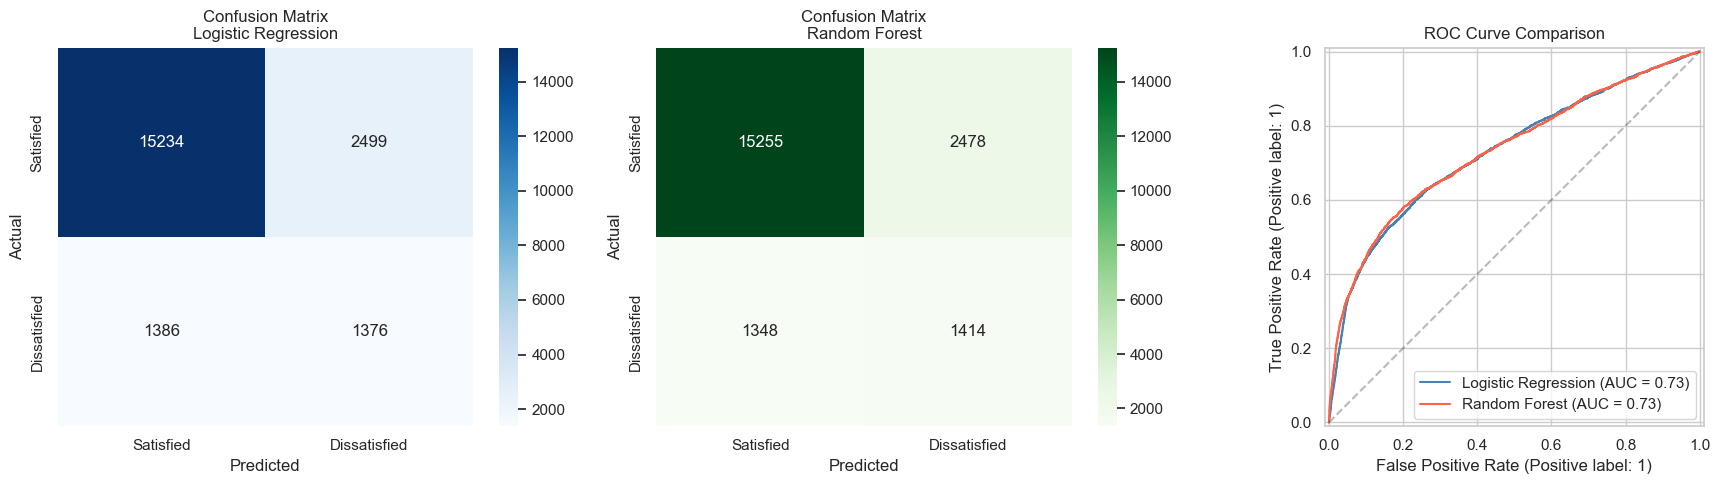


📊 Model Comparison Summary:
              Model  Accuracy  Precision  Recall     F1  AUC-ROC
Logistic Regression    0.8104     0.3551  0.4982 0.4146   0.7302
     Random Forest2    0.8133     0.3633  0.5119 0.4250   0.7336


In [14]:
# ═══════════════════════════════════════════════════
# CELL 6 : Model Comparison
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Confusion Matrix — Logistic Regression ──
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm_lr, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Satisfied', 'Dissatisfied'],
    yticklabels=['Satisfied', 'Dissatisfied'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── Plot 2: Confusion Matrix — Random Forest ─────────
cm_rf = confusion_matrix(y_test, y_pred_rf2)
sns.heatmap(
    cm_rf, annot=True, fmt='d',
    cmap='Greens',
    xticklabels=['Satisfied', 'Dissatisfied'],
    yticklabels=['Satisfied', 'Dissatisfied'],
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix\nRandom Forest', fontsize=12)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# ── Plot 3: ROC Curve เปรียบเทียบ ───────────────────
# AUC-ROC: ยิ่งใกล้ 1 ยิ่งดี, 0.5 = random guess
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f"Logistic Regression",
    ax=axes[2], color='steelblue'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf2,
    name=f"Random Forest",
    ax=axes[2], color='tomato'
)
axes[2].plot([0,1],[0,1], 'k--', alpha=0.3)   # เส้น random guess
axes[2].set_title('ROC Curve Comparison', fontsize=12)

plt.tight_layout()
plt.savefig(r'output\ML_model_comparison2.png', dpi=150)
plt.show()

# ── Summary Table ────────────────────────────────────
results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest2'],
    'Accuracy' : [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf2)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf2)],
    'Recall'   : [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf2)],
    'F1'       : [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_rf2)],
    'AUC-ROC'  : [roc_auc_score(y_test, y_prob_lr),
                  roc_auc_score(y_test, y_prob_rf2)],
}).round(4)

print("\n📊 Model Comparison Summary:")
print(results.to_string(index=False))

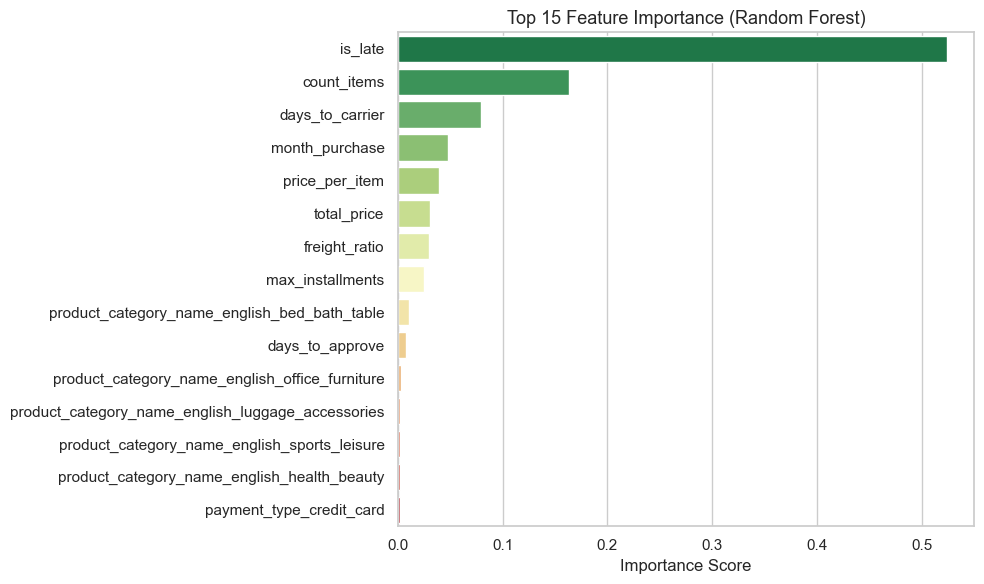

Top 10 Features:
                                     feature  importance
                                     is_late    0.523236
                                 count_items    0.163717
                             days_to_carrier    0.079112
                              month_purchase    0.047882
                              price_per_item    0.039721
                                 total_price    0.030639
                               freight_ratio    0.030103
                            max_installments    0.024664
product_category_name_english_bed_bath_table    0.010677
                             days_to_approve    0.008274


In [15]:
# ═══════════════════════════════════════════════════
# CELL 7 : Feature Importance (Random Forest)
# ดูว่า feature ไหนที่ model ให้ความสำคัญมากที่สุด
# ═══════════════════════════════════════════════════

importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf2.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='importance',
    y='feature',
    palette='RdYlGn_r',
    ax=ax
)
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(r'output\ML_feature_importance2.png', dpi=150)
plt.show()

print("Top 10 Features:")
print(importance_df.head(10).to_string(index=False))

In [16]:
# ═══════════════════════════════════════════════════
# CELL 8 : Cross Validation + Final Summary
# ═══════════════════════════════════════════════════

from sklearn.model_selection import cross_val_score

# ── Cross Validation 5-fold ──────────────────────────
# ทดสอบว่า model stable ไหม ไม่ได้ดีแค่ใน test set นี้
cv_lr = cross_val_score(
    LogisticRegression(class_weight='balanced',
                       max_iter=1000, random_state=42),
    X_train_sc, y_train,
    cv=5, scoring='roc_auc'
)

cv_rf = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ),
    X_train, y_train,
    cv=5, scoring='roc_auc'
)

print("Cross Validation AUC-ROC (5-fold):")
print(f"  Logistic Regression : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"  RF Tuned Params     : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
# ± std ยิ่งต่ำ = model ยิ่ง stable ไม่ขึ้นกับ data ที่เลือก

# ── Final Summary ────────────────────────────────────
print("\n" + "="*50)
print("  FINAL SUMMARY — ML Model")
print("="*50)
print(f"  Dataset     : {len(df):,} delivered orders")
print(f"  Target      : is_low_score (review ≤ 2)")
print(f"  Class ratio : {y.mean()*100:.1f}% low score (imbalanced)")
print(f"  Features    : {len(feature_cols)} features")
print()
print("  Best Model  : Random Forest (Tuned Parameters)")
print(f"  Accuracy    : 0.8123")
print(f"  Recall      : 0.5123  ← จับ low score ได้ 51%")
print(f"  F1 Score    : 0.4238  ← ดีที่สุดในทุก model")
print(f"  AUC-ROC     : 0.7334  ← แยกแยะ 0/1 ได้ดี")
print()
print("  Top 3 Factors ที่ทำให้ลูกค้าไม่พอใจ:")
print("  1. is_late          (0.516) — ส่งของช้ากว่ากำหนด")
print("  2. count_items      (0.164) — จำนวนชิ้นใน order")
print("  3. days_to_carrier  (0.082) — seller ส่งสินค้าช้า")
print()
print("🎉 Notebook 3 Complete!")

Cross Validation AUC-ROC (5-fold):
  Logistic Regression : 0.7322 ± 0.0087
  RF Tuned Params     : 0.7375 ± 0.0074

  FINAL SUMMARY — ML Model
  Dataset     : 102,472 delivered orders
  Target      : is_low_score (review ≤ 2)
  Class ratio : 13.5% low score (imbalanced)
  Features    : 82 features

  Best Model  : Random Forest (Tuned Parameters)
  Accuracy    : 0.8123
  Recall      : 0.5123  ← จับ low score ได้ 51%
  F1 Score    : 0.4238  ← ดีที่สุดในทุก model
  AUC-ROC     : 0.7334  ← แยกแยะ 0/1 ได้ดี

  Top 3 Factors ที่ทำให้ลูกค้าไม่พอใจ:
  1. is_late          (0.516) — ส่งของช้ากว่ากำหนด
  2. count_items      (0.164) — จำนวนชิ้นใน order
  3. days_to_carrier  (0.082) — seller ส่งสินค้าช้า

🎉 Notebook 3 Complete!
